In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
from scipy import stats

In [2]:
pio.renderers.default = "jupyterlab"
pio.templates.default = "seaborn"  # optional

### Импорт датасета

Датасет содержит
Имеется 21 колонка:

* `Row ID` - уникальный ID.
* `Order ID` - уникальный ID заказа для каждого покупателя.
* `Order Date` - дата заказа.
* `Ship Date` - дата доставки.
* `Ship Mode` - способ доставки (Стандартный, Второй класс, Первый класс, В тот же день).
* `Customer ID` - уникальный ID каждого покупателя.
* `Customer Name` - имя покупателя.
* `Segment` - какому сегменту принадлежит покупатель (Индивидуальный, Корпоративный и Домашний офис сегменты).
* `Country` - страна.
* `City` - город покупателя.
* `State` - штат покупятеля.
* `Postal Code` - почтовый код покупятеля.
* `Region` - регион покупателя (центр, юг, запад, восток).
* `Product ID` - уникальный ID продукта.
* `Category` - категория продукта: мебель, канцелярия и электроника.
* `Sub-Category` - подкатегория.
    1. Binders - папки
    2. Paper - бумага
    3. Furnishings - мебель
    4. Phones - смартфоны
    5. Storage - хранение
    6. Art - творчество
    7. Accessories - аксессуары
    8. Chairs - стулья
    9. Appliances - бытовая техника
    10. Labels - стикеры
    11. Tables - столы
    12. Envelopes - конверты
    13. Bookcases - книжные шкафы
    14. Fasteners - степлеры, кнопки, зажимы и т.д.
    15. Supplies - канцелярия
    16. Machines - техника
    17. Copiers - копиры
* `Product Name` - название продукта.
* `Sales` - продажи продукта.
* `Quantity` - количество продукта.
* `Discount` - скидка.
* `Profit` - прибыль (или убыток)

In [4]:
dtypes = {
    "Row ID": "int32",
    "Order ID": "string",
    "Order Date": "string",
    "Ship Date": "string",
    "Ship Mode": "category",
    "Customer ID": "string",
    "Customer Name": "string",
    "Segment": "category",
    "Country": "category",
    "City": "category",
    "State": "category",
    "Postal Code": "string",
    "Region": "category",
    "Product ID": "string",
    "Category": "category",
    "Sub-Category": "category",
    "Product Name": "string",
    "Sales": "float32",
    "Quantity": "int16",
    "Discount": "float32",
    "Profit": "float32",
}
df = pd.read_csv(
    filepath_or_buffer="data/Sample - Superstore.csv",
    encoding="latin1",
    dtype=dtypes,
    parse_dates=["Order Date", "Ship Date"],
)
pd.to_pickle(df, "data/dataset_orig.pkl")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int32         
 1   Order ID       9994 non-null   string        
 2   Order Date     9994 non-null   datetime64[ns]
 3   Ship Date      9994 non-null   datetime64[ns]
 4   Ship Mode      9994 non-null   category      
 5   Customer ID    9994 non-null   string        
 6   Customer Name  9994 non-null   string        
 7   Segment        9994 non-null   category      
 8   Country        9994 non-null   category      
 9   City           9994 non-null   category      
 10  State          9994 non-null   category      
 11  Postal Code    9994 non-null   string        
 12  Region         9994 non-null   category      
 13  Product ID     9994 non-null   string        
 14  Category       9994 non-null   category      
 15  Sub-Category   9994 n

In [5]:
df = pd.read_pickle("data/dataset_orig.pkl")

# Очистка данных

Ниже видим, что `Country` имеет только одно значение, нет дубликатов и NaN. Также избавляемся от ненужных столбцов, как `Customer Name` (так как у нас есть `Customer ID`) и т.д.

In [6]:
print(
    "Количество дубликатов:",
    df.duplicated().sum(),
    ", количество NaN:",
    df.isna().sum().sum(),
)
df.nunique()

Количество дубликатов: 0 , количество NaN: 0


Row ID           9994
Order ID         5009
Order Date       1237
Ship Date        1334
Ship Mode           4
Customer ID       793
Customer Name     793
Segment             3
Country             1
City              531
State              49
Postal Code       631
Region              4
Product ID       1862
Category            3
Sub-Category       17
Product Name     1850
Sales            5825
Quantity           14
Discount           12
Profit           7287
dtype: int64

In [7]:
df = (
    df.drop(
        [
            "Row ID",
            "Order ID",
            "Ship Date",
            "Customer Name",
            "Country",
            "Postal Code",
            "Region",
            "Product ID",
            "Product Name",
        ],
        axis=1,
    )
    .sort_values("Order Date")
    .reset_index(drop=True)
)

# Визуализация и анализ

### Ключевые метрики по штатам

Топ штатов по `Sales`, `Discount` и `Profit`. На графике хорошо видно, что бизнес терпит убытки в штате Техас, Иллинойс и некоторых других, что возможно связано с агрессивной дисконтной политикой.

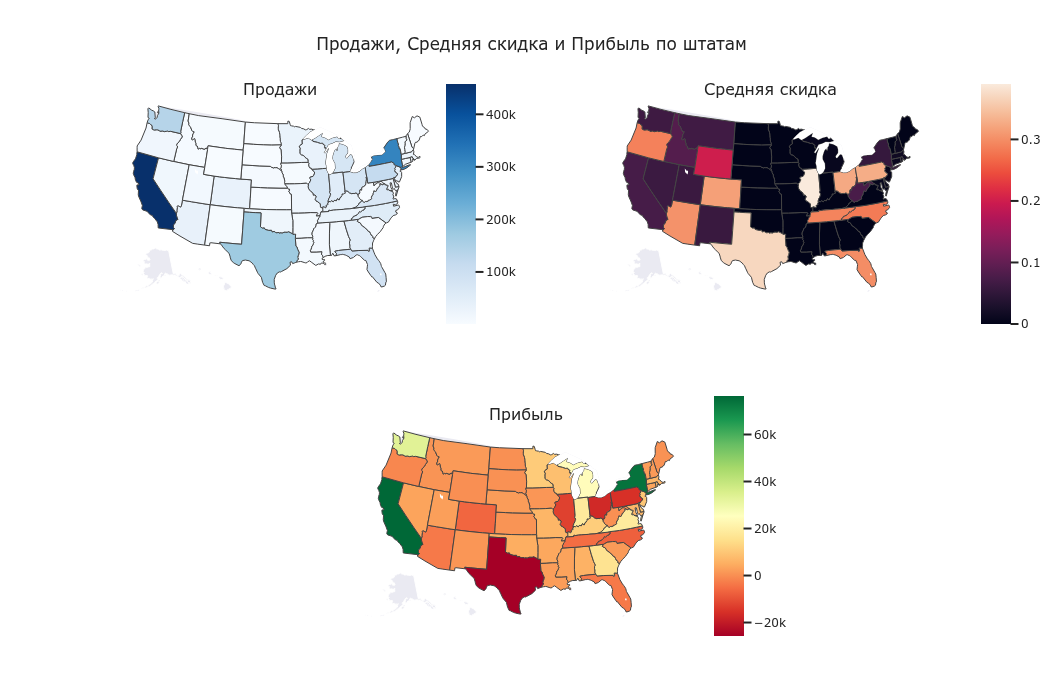

,State,Mean Discount
12,Illinois,0.390041
41,Texas,0.370193
36,Pennsylvania,0.328620
33,Ohio,0.324947
4,Colorado,0.316483


In [8]:
from plotly.subplots import make_subplots

state_abbr_map = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "District of Columbia": "DC",
}

df["State Abbr"] = pd.Series(map(lambda x: state_abbr_map[x], df["State"]))
temp = df.groupby(["State Abbr", "State"], observed=True, as_index=False)[
    ["Sales", "Profit", "Discount"]
].agg(
    **{
        "Sum Sales": ("Sales", "sum"),
        "Sum Profit": ("Profit", "sum"),
        "Mean Discount": ("Discount", "mean"),
    }
)

fig = make_subplots(
    rows=2,
    cols=2,
    subplot_titles=("Продажи", "Средняя скидка", "Прибыль"),
    specs=[
        [{"type": "choropleth"}, {"type": "choropleth"}],
        [{"type": "choropleth", "colspan": 2}, None],
    ],
)

sales_trace = go.Choropleth(
    locations=temp["State Abbr"],
    z=temp["Sum Sales"],
    locationmode="USA-states",
    colorscale="Blues",
    hovertemplate="<b>%{customdata[0]}</b><br>Продажи: $%{z}<extra></extra>",
    customdata=temp[["State"]],
    colorbar=dict(
        x=0.4,
        y=0.8,
        len=0.5,
        yanchor="middle",
    ),
)

discount_trace = go.Choropleth(
    locations=temp["State Abbr"],
    z=temp["Mean Discount"],
    locationmode="USA-states",
    hovertemplate="<b>%{customdata[0]}</b><br>Скидка: %{z}<extra></extra>",
    customdata=temp[["State"]],
    colorbar=dict(
        x=1.0,
        y=0.8,
        len=0.5,
        yanchor="middle",
    ),
)

profit_trace = go.Choropleth(
    locations=temp["State Abbr"],
    z=temp["Sum Profit"],
    locationmode="USA-states",
    colorscale="RdYlGn",
    hovertemplate="<b>%{customdata[0]}</b><br>Прибыль: $%{z}<extra></extra>",
    customdata=temp[["State"]],
    colorbar=dict(
        x=0.7,
        y=0.2,
        len=0.5,
        yanchor="middle",
    ),
)

# 4. Add the traces to the respective subplot cells
fig.add_trace(sales_trace, row=1, col=1)
fig.add_trace(discount_trace, row=1, col=2)
fig.add_trace(profit_trace, row=2, col=1)

# 5. Update the layout for map projections and general title
fig.update_layout(
    title_text="Продажи, Средняя скидка и Прибыль по штатам",
    geo=dict(scope="usa"),
    geo1=dict(scope="usa"),
    geo2=dict(scope="usa"),
    geo3=dict(scope="usa"),
    height=700,
)

df = df.drop(["State Abbr"], axis=1)

fig.show()

# temp[['State', 'Mean Discount']].sort_values(by=['Mean Discount'], axis=1, ascending=False).head(5)
temp[["State", "Mean Discount"]].sort_values("Mean Discount", ascending=False).head(5)

Продолжим анализ и рассмотрим `Profit` по `Sub-Category`

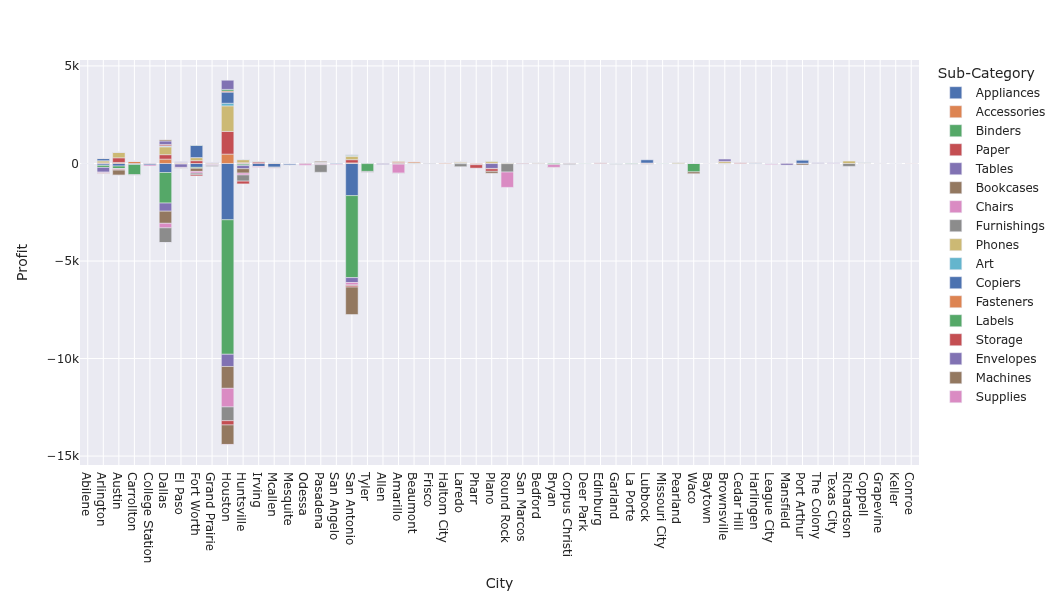

In [9]:
temp = (
    df[df["State"] == "Texas"]
    .groupby(["City", "Sub-Category"], observed=True)["Profit"]
    .sum()
    .to_frame()
    .reset_index()
)
px.bar(temp, x="City", y="Profit", color="Sub-Category", height=600)

### Взаимосвязь Discount и Profit

Построим зависимость `Profit` от `Discount`. На первый взгляд наша прибыль уменьшается при увеличении скидки, но зависимость может быть более сложна.

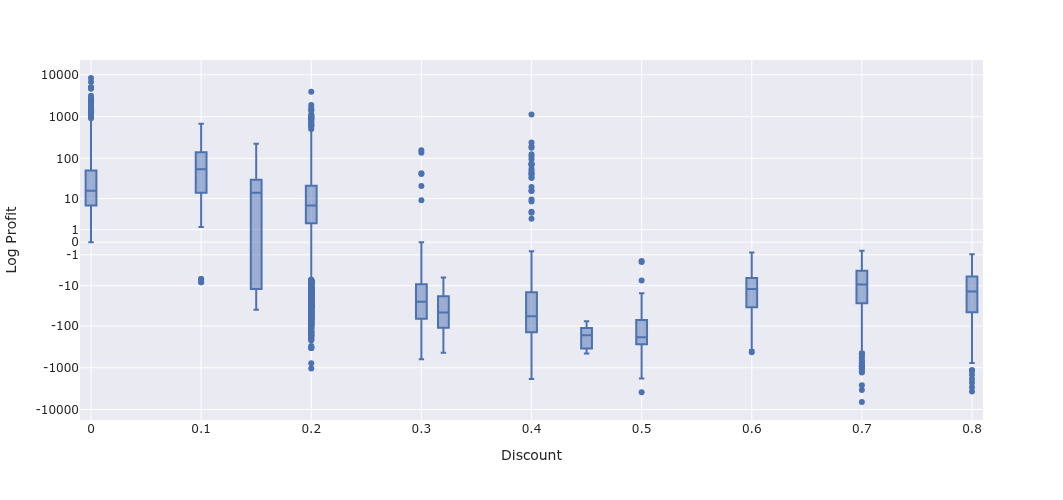

In [10]:
log_Profit = np.sign(df["Profit"]) * np.log1p(
    np.abs(df["Profit"])
)  # signed_log = sign(x) * log(1 + |x|)
temp = df.copy()
temp['Log Profit'] = log_Profit
fig = px.box(temp, y='Log Profit', x="Discount", height=500, hover_data={'Log Profit': False, 'Profit': True})
ticks = [-10000, -1000, -100, -10, -1, 0, 1, 10, 100, 1000, 10000]
fig.update_yaxes(
    tickvals=[np.sign(t) * np.log1p(abs(t)) for t in ticks],
    ticktext=[str(t) for t in ticks],
)

Рассмотрим `Profit` от каждого клиента в течение 90 дней после предоставления скидки

In [11]:
gp = df.groupby('Customer ID')
Profit_In_90d = pd.Series([np.nan] * df.shape[0])

for name, group in gp:
    for row_index, row in group[group['Discount'] > 0].iterrows():
        Profit_In_90d[row_index] = group[
            (row["Order Date"]
            <= group["Order Date"]) & (group["Order Date"]
            <= row["Order Date"] + pd.Timedelta(days=90))
        ]["Profit"].sum()
        
temp = df.copy()
temp['Profit In 90d'] = Profit_In_90d

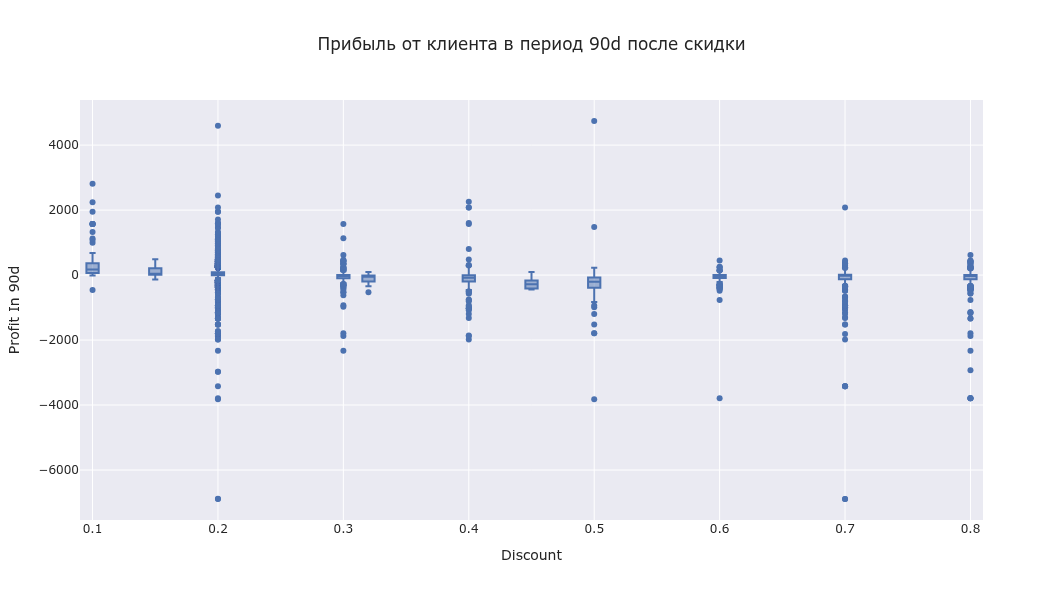

In [12]:
px.box(temp, x='Discount', y='Profit In 90d', title='Прибыль от клиента в период 90d после скидки', height=600)

### Высокоценные клиенты

Ниже видно, что еще одна из проблем, что топ покупатель по объему продаж приносит убытки

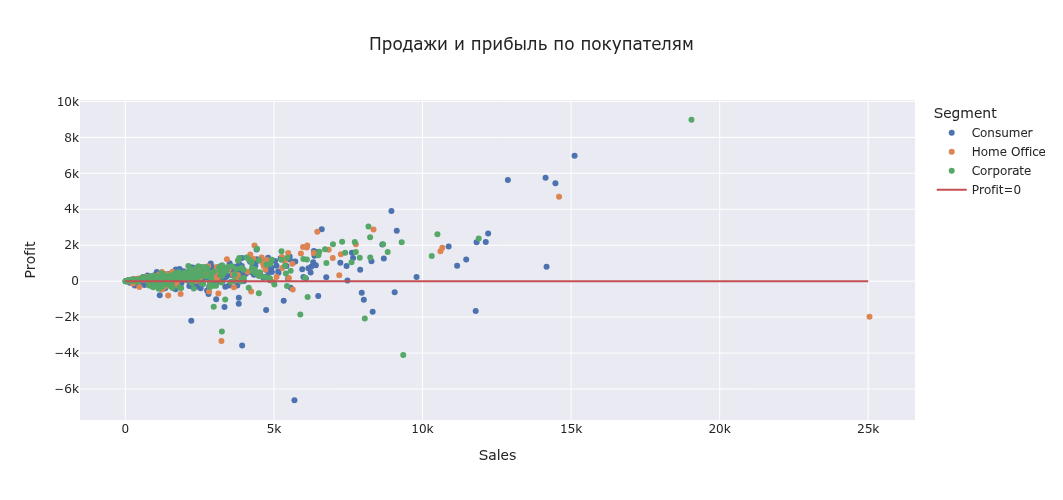

In [13]:
fig = px.scatter(
    df.groupby(["Customer ID", "Segment"], observed=True, as_index=False)[
        ["Sales", "Profit"]
    ].sum(),
    x="Sales",
    y="Profit",
    color="Segment",
    title="Продажи и прибыль по покупателям",
    hover_data=["Customer ID"],
    height=500,
)
fig.add_trace(
    go.Scatter(
        x=[0, 25e3],
        y=[0, 0],
        mode="lines",
        name="Profit=0",
    )
)

### Анализ временных рядов

Наблюдается сезонность: пик в ноябре/декабре, самые низкие показатели в январе/феврале

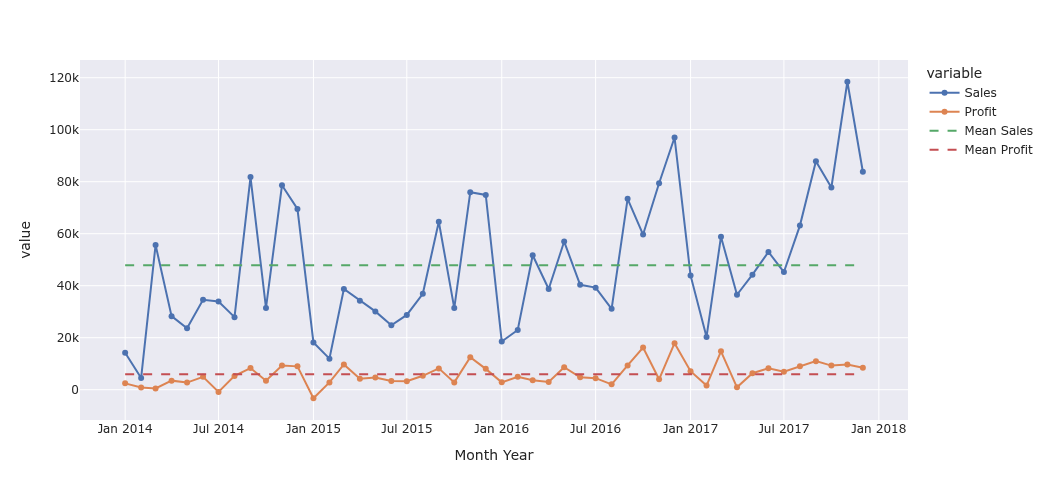

In [14]:
temp = df.groupby(df["Order Date"].dt.to_period("M")).agg(
    {"Profit": "sum", "Sales": "sum"}
)
temp["Month Year"] = temp.index.astype(str)
fig = px.line(temp, x="Month Year", y=["Sales", "Profit"], height=500, markers=True)
fig.add_traces(
    [
        go.Scatter(
            x=["2014-01", "2017-12"],
            y=[temp["Sales"].mean(), temp["Sales"].mean()],
            mode="lines",
            line={"dash": "dash"},
            name="Mean Sales",
        ),
        go.Scatter(
            x=["2014-01", "2017-12"],
            y=[temp["Profit"].mean(), temp["Profit"].mean()],
            mode="lines",
            line={"dash": "dash"},
            name="Mean Profit",
        ),
    ]
)

### Распределение ключевых метрик по категориям товаров

Можно пронаблюдать, что товары с категорией `Tables` нерентабельна и требует пересмотра ценовой политики.

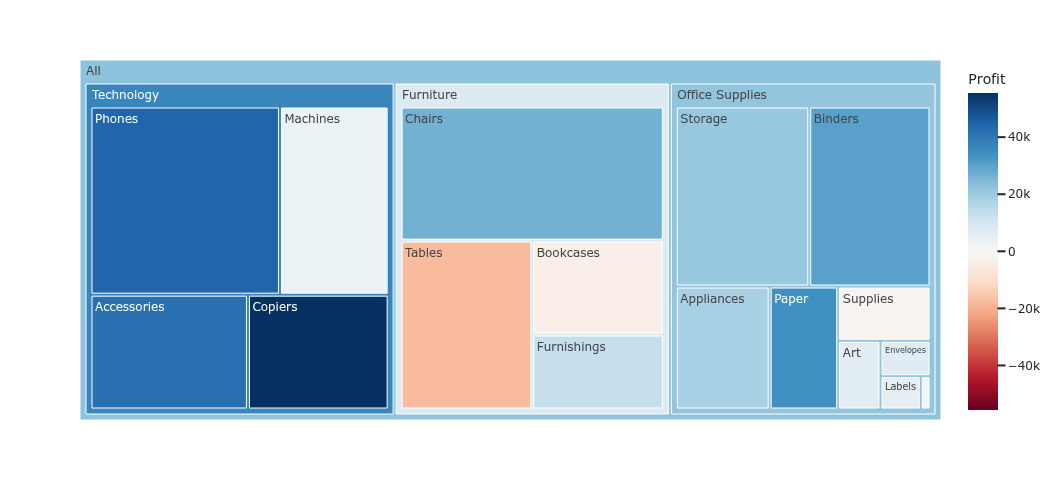

In [15]:
temp = (
    df.groupby(["Category", "Sub-Category"], observed=True)[["Sales", "Profit"]]
    .agg("sum")
    .reset_index()
)
px.treemap(
    temp,
    path=[px.Constant("All"), "Category", "Sub-Category"],
    values="Sales",
    color="Profit",
    color_continuous_scale="RdBu",
    color_continuous_midpoint=0.0,
    height=500,
)

In [16]:
df.groupby(["Category", "Sub-Category"], observed=True)["Discount"].agg("describe")

count      mean       std  min   25%  50%  \
Category        Sub-Category                                               
Furniture       Bookcases      228.0  0.211140  0.191913  0.0  0.00  0.2   
                Chairs         617.0  0.170178  0.107444  0.0  0.10  0.2   
                Furnishings    957.0  0.138349  0.207804  0.0  0.00  0.0   
                Tables         319.0  0.261285  0.169622  0.0  0.20  0.3   
Office Supplies Appliances     466.0  0.166524  0.272771  0.0  0.00  0.0   
                Art            796.0  0.074874  0.096853  0.0  0.00  0.0   
                Binders       1523.0  0.372292  0.310938  0.0  0.20  0.2   
                Envelopes      254.0  0.080315  0.098237  0.0  0.00  0.0   
                Fasteners      217.0  0.082028  0.098599  0.0  0.00  0.0   
                Labels         364.0  0.068681  0.095100  0.0  0.00  0.0   
                Paper         1370.0  0.074891  0.096832  0.0  0.00  0.0   
                Storage        846.0  0.074704  0.096805  0.0  0.00  0.0   
                Supplies       190.0  0.076842  0.097539  0.0  0.00  0.0   
Technology      Accessories    775.0  0.078452  0.097714  0.0  0.00  0.0   
                Copiers         68.0  0.161765  0.130475  0.0  0.00  0.2   
                Machines       115.0  0.306087  0.252804  0.0  0.05  0.2   
                Phones         889.0  0.154556  0.129813  0.0  0.00  0.2   

                               75%  max  
Category        Sub-Category             
Furniture       Bookcases     0.32  0.7  
                Chairs        0.30  0.3  
                Furnishings   0.20  0.6  
                Tables        0.40  0.5  
Office Supplies Appliances    0.20  0.8  
                Art           0.20  0.2  
                Binders       0.70  0.8  
                Envelopes     0.20  0.2  
                Fasteners     0.20  0.2  
                Labels        0.20  0.2  
                Paper         0.20  0.2  
                Storage       0.20  0.2  
                Supplies      0.20  0.2  
Technology      Accessories   0.20  0.2  
                Copiers       0.20  0.4  
                Machines      0.50  0.7  
                Phones        0.20  0.4

### Анализ распределения `Sales`

Известно, что цены на товары и прочие некоторые финансовые метрики имеют распределения с тяжелыми хвостами. Построим `log-log` график `x vs 1 - cdf(x)` для переменной `Sales`. Видно, что хвост имеет вид прямой, поэтому наше предположение подтвеждается.

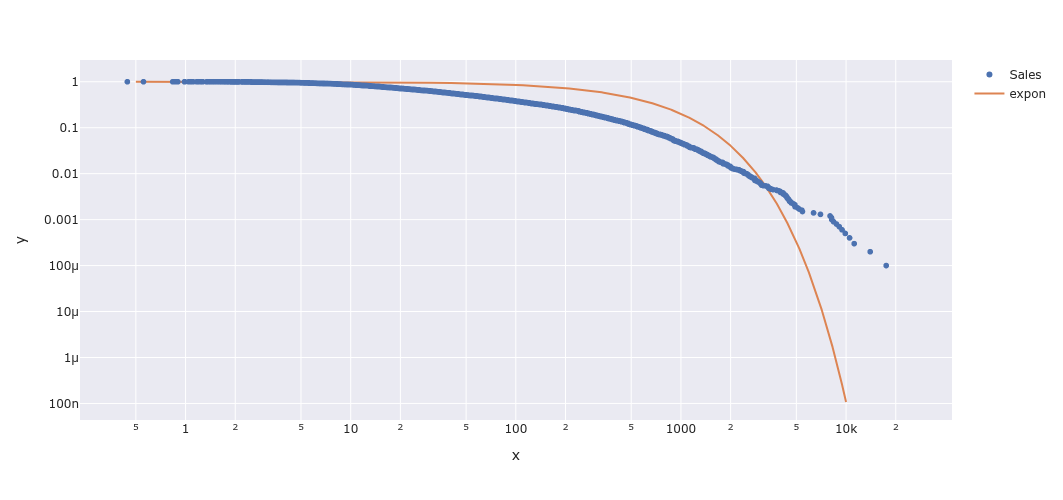

In [17]:
fig = px.scatter(
    x=df["Sales"].sort_values(),
    y=1 - np.arange(1, len(df) + 1) / len(df),
    log_x=True,
    log_y=True,
    height=500,
)
fig.data[0].name = "Sales"
fig.data[0].showlegend = True
n = 1000
temp = np.linspace(0.5, 10000, n)
fig.add_trace(
    go.Scatter(
        x=temp,
        y=1 - stats.expon(loc=0, scale=df["Sales"].std()).cdf(temp),
        mode="lines",
        name="expon",
    )
)